# Optimization of a Quantum Circuit with a Genetic Algorithm

## Introduction
This notebook presents the implementation of a genetic algorithm to approximate a target unitary matrix using quantum circuits.

Our goal is to use evolutionary techniques to generate quantum circuits that best approximate a given target circuit (expressed as a unitary matrix).




In [101]:
## Imports
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
import matplotlib.pyplot as plt
import copy
import random
from joblib import Parallel, delayed

# Step 1: Generation of Quantum Circuits

## Objective

The purpose of this section is to randomly generate a **population of quantum circuits**, represented as chromosomes. Each circuit is a sequence of quantum gates encoded as genes. This random generation constitutes the **initial population** for a genetic optimization algorithm.

---

## Structure of a Gene

A **gene** is a quantum instruction that contains:
- A quantum gate (from a chosen set),
- The target qubit,
- Optionally a control qubit (for gates like `CX`),
- Optionally an angle (for rotation gates like `RX`, `RY`, `RZ`).

---


In [102]:
# -------------------- Circuit generation --------------------

def generate_gene(num_qubits):
    """
    Generate a random gene representing a quantum gate.
    """
    quantum_gates = {
        "H": {"control": False, "rotation": False},
        "X": {"control": False, "rotation": False},
        "Y": {"control": False, "rotation": False},
        "Z": {"control": False, "rotation": False},
        "CX": {"control": True, "rotation": False},
        "CCX": {"control": True, "rotation": False},
        "CZ": {"control": True, "rotation": False},
        "RX": {"control": False, "rotation": True},
        "RY": {"control": False, "rotation": True},
        "RZ": {"control": False, "rotation": True}
    }

    target_qubit = np.random.randint(num_qubits)
    gate = np.random.choice(list(quantum_gates.keys()))
    control_qubit = None
    angle = None

    if gate == "CCX":
        # Choose 2 control qubits different from the target
        possible_controls = list(set(range(num_qubits)) - {target_qubit})
        control_qubit = np.random.choice(possible_controls, size=2, replace=False).tolist()
    elif quantum_gates[gate]["control"]:
        control_qubit = np.random.randint(num_qubits)
        while control_qubit == target_qubit:
            control_qubit = np.random.randint(num_qubits)

    if quantum_gates[gate]["rotation"]:
        angle = np.random.uniform(0, 2 * np.pi)

    return [target_qubit, gate, control_qubit, angle]


### Explanation

- We start by randomly choosing a gate (`gate`) from a predefined dictionary of gates.
- We then draw a **target qubit** (`target_qubit`) between `0` and `num_qubits - 1`.
- If the gate is controlled (`CX`), a control qubit is selected, different from the target qubit.
- If the gate is a rotation gate (`RX`, `RY`, `RZ`), a random angle between 0 and 2π is generated.
- The returned gene is a list containing all these elements.

---

## Generation of a Chromosome

A **chromosome** is a sequence (list) of genes representing an entire quantum circuit.


In [103]:
def generate_chromosome(num_qubits, num_genes):
    """
    Generate a chromosome, i.e. a sequence of genes.

    Args:
        num_qubits (int): number of qubits in the circuit.
        num_genes (int): number of gates (genes) in the circuit.

    Returns:
        list: a list of genes.
    """
    return [generate_gene(num_qubits) for _ in range(num_genes)]


## Generation of a Population

We now generate several chromosomes to form an **initial population**.


In [104]:
def generate_population(pop_size, num_qubits, num_genes):
    """
    Generate a population of chromosomes.

    Args:
        pop_size (int): number of circuits in the population.
        num_qubits (int): number of qubits per circuit.
        num_genes (int): number of gates per circuit.

    Returns:
        list: a list of chromosomes.
    """
    return [generate_chromosome(num_qubits, num_genes) for _ in range(pop_size)]


---

## Creating a Quantum Circuit from a Chromosome

Once a chromosome has been generated, it can be translated into an executable Qiskit circuit:


In [105]:
def create_quantum_circuit(chromosome, num_qubits):
    """
    Transform a chromosome (list of genes) into a Qiskit quantum circuit.

    Args:
        chromosome (list): list of genes.
        num_qubits (int): number of qubits in the circuit.

    Returns:
        QuantumCircuit: the corresponding quantum circuit.
    """
    circuit = QuantumCircuit(num_qubits)
    for gene in chromosome:
        target, gate, control, angle = gene
        if gate in ["H", "X", "Y", "Z"]:
            getattr(circuit, gate.lower())(target)
        elif gate == "CX":
            circuit.cx(control, target)
        elif gate == "CCX":
            circuit.ccx(control[0], control[1], target)
        elif gate == "CZ":
            circuit.cz(control, target)
        elif gate in ["RX", "RY", "RZ"]:
            getattr(circuit, gate.lower())(angle, target)
    return circuit


## 🧮 Fitness Function: Fidelity between Circuits

### ✅ Mathematical Formula

The fitness function implements the following formula:

$$
\text{correctness}(C) = \frac{|\text{tr}(G^\dagger \cdot \lambda(C))|}{2^n} \quad \text{(equation 5.7)}
$$

where:

- $\lambda(C)$ is the unitary matrix generated by the candidate circuit $C$,
- $G$ is the target unitary matrix,
- $n$ is the number of qubits.

---

### 🧠 Purpose of this Formula

- It measures how faithfully a candidate circuit $C$ reproduces the behavior of the target unitary $G$.
- The result is **normalized between 0 and 1**:
  - $1$ means that $C \sim e^{i\theta} G$ (equivalent up to a global phase),
  - $0$ means no correspondence.

---

### 📐 Why does this Formula Work?

#### 🎯 1. Hilbert-Schmidt Inner Product

This formula is derived from the **Hilbert-Schmidt inner product**, used to compare two unitary operators:

$$
F(U, V) = \frac{|\text{tr}(U^\dagger V)|}{2^n}
$$

It captures the **overall closeness** between two circuits in Hilbert space.

---

#### 🔄 2. Global Phase Invariance

Suppose that:

$$
\lambda(C) = e^{i\theta} G
$$

Then:

$$
\text{tr}(G^\dagger \cdot \lambda(C)) = \text{tr}(G^\dagger \cdot e^{i\theta} G) = e^{i\theta} \cdot \text{tr}(G^\dagger G) = e^{i\theta} \cdot \text{tr}(I) = e^{i\theta} \cdot 2^n
$$

And therefore:

$$
\frac{|\text{tr}(G^\dagger \cdot \lambda(C))|}{2^n} = \frac{|e^{i\theta}| \cdot 2^n}{2^n} = 1
$$

✅ Fidelity is therefore **invariant to global phase**, which is **physically correct**.

---

### ⚠️ Complexity

- A **full unitary matrix** of size $2^n \times 2^n$ must be computed.
- This computation becomes **exponentially expensive** once $n > 10$.
- Hence the value of using optimized libraries such as **BLAS** for performance.

---

### 💰 Other Possible Components in the Fitness

| Component      | Description |
|----------------|-------------|
| `cost(C)`      | Cost of the circuit (number/type of gates, depth, etc.) |
| `feasible(C)`  | Physical feasibility of the circuit (connectivity, topology) |

---

### 📚 References

- Nielsen & Chuang, *Quantum Computation and Quantum Information*, section 4.2.3
- Qiskit Textbook — [Average gate fidelity](https://qiskit.org/textbook/ch-quantum-hardware/quantum-errors.html)
- *Wabisabi: A Toolkit for Evolutionary Design of Quantum Circuits* — section 5.2
- John Preskill's notes — *Kraus operators and fidelity*

---

### 💡 Summary

- `compute_fitness` measures the **overall fidelity** between a circuit and a target unitary.
- It is **robust to global phase**.
- It is **expensive** but **accurate**.


In [106]:

# -------------------- Fitness function --------------------

def compute_fitness(circuit, target_unitary):
    candidate_unitary = Operator(circuit).data
    target_dagger = np.conj(target_unitary.T)
    trace_value = np.trace(np.dot(candidate_unitary, target_dagger))
    num_qubits = circuit.num_qubits
    return np.abs(trace_value) / (2 ** num_qubits)


---

## Parallel Evaluation of the Whole Population

To speed up the process, especially when the population is large, we use **parallel processing** via `joblib`.

Each chromosome in the population is converted into a quantum circuit, then compared to the target circuit.


In [107]:

def parallel_fitness(population, num_qubits, target_unitary):
    return Parallel(n_jobs=-1)(
        delayed(compute_fitness)(create_quantum_circuit(chromo, num_qubits), target_unitary)
        for chromo in population
    )


# Selection Methods

## 🎯 Objective

**Selection** is a crucial step in a genetic algorithm. It allows the best individuals (or chromosomes) from the current population to be chosen in order to produce the next generation.

It generally relies on the **fitness** of each individual, and must strike a balance between:
- **Exploitation**: favoring the best individuals,
- **Exploration**: maintaining genetic diversity to avoid local minima.

---

## ✅ Methods Tested

### 1. 🎲 Stochastic Universal Sampling (SUS)

This method is a more stable version of roulette selection, which evenly distributes selections across the population based on cumulative fitness.

- `num_selected` equidistant pointers are placed on the fitness wheel.
- This guarantees a minimum diversity while remaining proportional to fitness.



In [108]:
# -------------------- stochastic selection --------------------
import random

def stochastic_universal_sampling(population, fitnesses, num_selected):

    total_fitness = np.sum(fitnesses)
    pointers = []
    distance = total_fitness / num_selected
    start_point = random.uniform(0, distance)

    for i in range(num_selected):
        pointers.append(start_point + i * distance)

    selected = []
    cumulative_fitness = 0.0
    idx = 0

    for pointer in pointers:
        while cumulative_fitness < pointer:
            cumulative_fitness += fitnesses[idx]
            idx += 1
        selected.append(population[idx - 1])

    return selected



### 1. 🎲 Roulette Wheel Selection
This is the most classic method:

Each individual has a probability proportional to its fitness.

It can sometimes over-select the best individuals, which reduces diversity.

In [109]:
# -------------------- Roulette wheel selection --------------------

def roulette_wheel_selection(population, fitness_values, num_selected):
    # Compute the total fitness (sum of fitness values of all individuals)
    F_total = np.sum(fitness_values)

    # Compute the selection probability for each individual
    probabilities = fitness_values / F_total

    # Select individual indices according to their probabilities
    selected_indices = np.random.choice(len(population), size=num_selected, p=probabilities)

    # Return the selected individuals using the indices
    selected = [population[idx] for idx in selected_indices]

    return selected



# 📈 Rank Selection
Here, the population is sorted by fitness and probabilities are assigned based on rank (rather than the raw fitness value).

Advantages:

Prevents very strong individuals from dominating too quickly.

Reduces the risk of stagnation.

In [110]:
# -------------------- Rank Selection --------------------
def rank_selection(population, fitness_values, num_selected):
    """
    Select individuals based on their rank (rather than their raw fitness).
    """
    sorted_indices = np.argsort(fitness_values)[::-1]  # Sort indices by decreasing fitness
    ranks = np.arange(len(population), 0, -1)  # Assign a rank (best = highest)

    # Compute probabilities based on ranks
    rank_probabilities = ranks / np.sum(ranks)

    # Select individuals according to rank probabilities
    selected_indices = np.random.choice(len(population), size=num_selected, p=rank_probabilities, replace=True)

    return [population[i] for i in selected_indices]

# 🔁 Mutation in the Genetic Algorithm

## 🎯 Objective

**Mutation** is an essential operation that introduces diversity into the population by modifying existing chromosomes.
It allows exploring new regions of the search space and avoids getting stuck in local minima.

---

## 🧬 Types of Mutation Applied

In our case, each **chromosome** is a sequence of **quantum gates** applied to a circuit.
We combined several complementary types of mutation:

---

### 1. 🧠 Classic Mutation (random substitution)

- Certain gates of the chromosome are randomly modified.
- A mutation rate `mutation_rate` determines the probability of performing this operation.
- Up to `max_mutations` genes of the chromosome are replaced with new random genes.

---

### 2. 🧱 Structural Mutation (addition or removal)

The **structure of the circuit** is modified by:

- 🔺 **Addition** of a gate: inserting a new gene at a random position.
- 🔻 **Removal** of a gate: removing a random gene from the chromosome.

This mutation is accepted or rejected according to a **simulated annealing** logic, which allows temporarily accepting worse solutions if they might lead to better solutions later.

---

### 🔥 Simulated Annealing

A mutation that **slightly decreases** fitness can be accepted with a probability given by:

$$
P = \exp\left(\frac{\Delta}{T}\right)
$$

where:

- $\Delta$ is the **negative change** in fitness,
- $T$ is the **temperature**, which decreases over the generations.

✅ This allows **escaping local minima** by temporarily accepting suboptimal mutations.

---

### 📉 Dynamic Adjustment of the Mutation Rate

The `adjust_mutation_rate` function dynamically adapts the mutation rate:

- ✅ If **fitness stagnates** for too long, the mutation rate is **increased** (exploration),
- 📉 Otherwise, it is **gradually reduced** over the generations (exploitation).

This helps better balance **exploration and convergence** in the evolution of the population.

---

## 🧪 Summary

| Mutation Type              | Purpose                            | Notes                                          |
|-----------------------------|------------------------------------|-------------------------------------------------|
| Classic mutation           | Global diversification            | Randomly replaces genes                        |
| Structural mutation        | Topology change                    | Can shorten or lengthen the circuit             |
| Angle mutation              | Local refinement                   | Slightly adjusts rotation gates                 |
| Simulated annealing         | Probabilistic acceptance           | Allows escaping a local minimum                 |
| Adaptive mutation rate      | Exploration/convergence balance    | Increased in case of stagnation                 |


In [111]:
# -------------------- Mutation --------------------

def mutate_structure(chromosome, num_qubits, target_unitary, generation, initial_temp, cooling_rate):
    """
    Applies a structural mutation: adding or removing a gate.
    Uses simulated annealing logic to decide whether the mutation is accepted.
    """
    original = chromosome.copy()
    original_fitness = compute_fitness(create_quantum_circuit(original, num_qubits), target_unitary)

    # Copy for mutation
    mutated = copy.deepcopy(chromosome)

    # Choose mutation: addition or removal
    if np.random.rand() < 0.5 and len(mutated) > 1:
        # 🔻 Removal of a gate
        del_idx = np.random.randint(len(mutated))
        del mutated[del_idx]
    else:
        # 🔺 Addition of a gate
        new_gate = generate_gene(num_qubits)
        insert_idx = np.random.randint(0, len(mutated) + 1)
        mutated.insert(insert_idx, new_gate)

    # Evaluate the mutated version
    mutated_fitness = compute_fitness(create_quantum_circuit(mutated, num_qubits), target_unitary)

    # Acceptance logic (simulated annealing)
    if mutated_fitness >= original_fitness:
        return mutated
    else:
        delta = mutated_fitness - original_fitness
        T = initial_temp * (cooling_rate ** generation)
        acceptance_probability = np.exp(delta / T)
        if np.random.rand() < acceptance_probability:
            return mutated
        else:
            return original  # Rejected


def mutate(chromosome, num_qubits, mutation_rate, max_mutations, target_unitary, generation, initial_temp, cooling_rate):
        original = chromosome.copy()
        original_fitness = compute_fitness(create_quantum_circuit(original, num_qubits), target_unitary)

        if np.random.rand() < mutation_rate:
            num_genes = len(chromosome)
            max_mutations = min(max_mutations, num_genes)
            num_mutations = np.random.randint(1, max_mutations + 1)
            mutation_indices = np.random.choice(num_genes, size=num_mutations, replace=False)

            for idx in mutation_indices:
                chromosome[idx] = generate_gene(num_qubits)

            mutated_fitness = compute_fitness(create_quantum_circuit(chromosome, num_qubits), target_unitary)

            if mutated_fitness < original_fitness:
                delta = mutated_fitness - original_fitness
                T = initial_temp * (cooling_rate ** generation)
                acceptance_probability = np.exp(delta / T)

                if np.random.rand() > acceptance_probability:
                    chromosome = original  # Reject mutation
            # ➕ Structural mutation as a complement (addition or removal)
        chromosome = mutate_structure(chromosome, num_qubits, target_unitary, generation, initial_temp, cooling_rate)
        #chromosome = update_rotation_angles(chromosome, num_qubits, target_unitary, eta_range=[0.01, 0.1, 0.5], delta=0.1)
        #chromosome = optimize_rotation_angles_spsa(chromosome, num_qubits, target_unitary, maxiter=30)



        return chromosome


# dynamic adjustment of the mutation rate

def adjust_mutation_rate(base_rate, generation, max_generations, stagnation_counter, stagnation_threshold=20):
    """
    Dynamically adjusts the mutation rate:
    - increases in case of stagnation
    - gradually decreases in case of improvement
    """
    # In case of prolonged stagnation: double it
    if stagnation_counter >= stagnation_threshold:
        return min(1.0, base_rate * 2)

    # Otherwise, gradual reduction over the generations
    decay = 0.5 * (1 - (generation / max_generations))
    return max(0.01, base_rate * (1 + decay))

# 🔀 Crossover

## 🎯 Objective

**Crossover** is a genetic operation that combines two parents (existing solutions) to produce **new individuals (children)**.
This allows **recombining effective sequences** of quantum gates in the hope of creating better circuits.

---

## 🧬 Strategy Used: One-Point Crossover

The method used here is a **uniform one-point crossover**, inspired by classic genetic algorithms.

### ⚙️ How it works:

1. A **minimum length** is determined between the two parents.
2. A random **cut point** is chosen between 1 and this length.
3. Two children are created:
   - `child1`: first part of `parent1` + second part of `parent2`,
   - `child2`: first part of `parent2` + second part of `parent1`.

### 📌 Conditions:

- If the minimum length is less than 2 (i.e. one of the parents has too few genes), the crossover is **skipped**.



In [112]:
#--------------------- Crossover --------------------

def crossover(parent1, parent2):
        min_length = min(len(parent1), len(parent2))
        if min_length < 2:
            return parent1, parent2

        cut_point = np.random.randint(1, min_length)
        child1 = parent1[:cut_point] + parent2[cut_point:]
        child2 = parent2[:cut_point] + parent1[cut_point:]
        return child1, child2

# 🎯 Local Optimization of Rotation Angles

## 🎯 Objective

Some genes in the chromosome represent **rotation gates** (`RX`, `RY`, `RZ`) that depend on an angle $\theta$.
The goal here is to **locally refine these angles** to maximize the fidelity of the generated quantum circuit.

---

## ⚙️ `update_rotation_angles` Function

This function adjusts the angles $\theta$ of the rotation gates present in a chromosome via a **local optimization based on gradient estimation**.
It acts as a form of **gradient descent** specific to the circuit's continuous parameters.

---

## 🧠 Algorithm Idea

1. For each gene of type `RX`, `RY` or `RZ`, we consider the current angle $\theta$.
2. We evaluate the circuit's fitness after a small displacement around $\theta$:

$$
\text{gradient} \approx \frac{F(\theta + \delta) - F(\theta - \delta)}{2\delta}
$$

3. We update the angle according to the rule:

$$
\theta_{\text{new}} = \theta + \eta \cdot \text{gradient}
$$

where:

- $\eta \in \text{eta_range}$ is a **learning rate** tested via grid search,
- $\delta$ is a small step used for the centered gradient estimation,
- We keep the value of $\eta$ that maximizes the **fitness** of the updated circuit.

---

## 🔧 Parameters

- `eta_range`: list of learning rates to test (e.g. `[0.01, 0.1, 0.5]`),
- `delta`: small step used to approximate the gradient by finite differences,
- The function returns a **new chromosome** with optimized angles.

---

## ✅ Advantages

- Allows fine exploitation of the **continuous parameter** space (angles),
- Acts as a **local micro-optimization** complementary to global mutation,
- Compatible with **simulated annealing**, **adaptive mutation**, and other stochastic mechanisms.

---

## 🧪 In Practice

This local refinement is called **after** the classic crossover and mutation steps, to polish the candidate solution.
It can also be used iteratively for further optimization.




In [113]:
def update_rotation_angles(chromosome, num_qubits, target_unitary, eta_range=[0.01, 0.1, 0.5], delta=0.1):
    best_chromosome = chromosome.copy()
    for i in range(len(best_chromosome)):
        if best_chromosome[i][1] in ["RX", "RY", "RZ"] and best_chromosome[i][3] is not None:
            theta = best_chromosome[i][3]
            best_eta = eta_range[0]
            best_fitness = 0
            for eta in eta_range:
                best_chromosome[i][3] = theta + delta
                circuit_plus = create_quantum_circuit(best_chromosome, num_qubits)
                F_plus = compute_fitness(circuit_plus, target_unitary)
                best_chromosome[i][3] = theta - delta
                circuit_minus = create_quantum_circuit(best_chromosome, num_qubits)
                F_minus = compute_fitness(circuit_minus, target_unitary)
                gradient = (F_plus - F_minus) / (2 * delta)
                new_theta = theta + eta * gradient
                best_chromosome[i][3] = new_theta
                circuit_updated = create_quantum_circuit(best_chromosome, num_qubits)
                new_fitness = compute_fitness(circuit_updated, target_unitary)
                if new_fitness > best_fitness:
                    best_fitness = new_fitness
                    best_eta = eta
                    best_chromosome[i][3] = new_theta
            
    return best_chromosome


In [114]:
"""import copy
import numpy as np
from qiskit.quantum_info import Operator

def update_rotation_angles(chromosome, num_qubits, target_unitary, eta=0.01, delta=0.1):

    best_chromosome = copy.deepcopy(chromosome)  # Deep copy to avoid unintended modifications

    for i in range(len(best_chromosome)):
        if best_chromosome[i][1] in ["RX", "RY", "RZ"] and best_chromosome[i][3] is not None:
            theta = best_chromosome[i][3]

            # Approximate the fitness gradient using centered finite differences
            best_chromosome[i][3] = theta + delta
            circuit_plus = create_quantum_circuit(best_chromosome, num_qubits)
            F_plus = compute_fitness(circuit_plus, target_unitary)

            best_chromosome[i][3] = theta - delta
            circuit_minus = create_quantum_circuit(best_chromosome, num_qubits)
            F_minus = compute_fitness(circuit_minus, target_unitary)

            # Compute the gradient
            gradient = (F_plus - F_minus) / (2 * delta)

            # Check for a significant gradient to avoid unnecessary updates
            if abs(gradient) > 1e-6:
                # Adapt the learning rate
                adaptive_eta = min(0.5, max(0.05, eta * abs(gradient)))
                best_chromosome[i][3] = theta + adaptive_eta * gradient

    return best_chromosome"""

'import copy\nimport numpy as np\nfrom qiskit.quantum_info import Operator\n\ndef update_rotation_angles(chromosome, num_qubits, target_unitary, eta=0.01, delta=0.1):\n    \n    best_chromosome = copy.deepcopy(chromosome)  # Copie profonde pour éviter les modifications involontaires\n\n    for i in range(len(best_chromosome)):\n        if best_chromosome[i][1] in ["RX", "RY", "RZ"] and best_chromosome[i][3] is not None:\n            theta = best_chromosome[i][3]\n\n            # Approximation du gradient de fitness par différences finies centrées\n            best_chromosome[i][3] = theta + delta\n            circuit_plus = create_quantum_circuit(best_chromosome, num_qubits)\n            F_plus = compute_fitness(circuit_plus, target_unitary)\n\n            best_chromosome[i][3] = theta - delta\n            circuit_minus = create_quantum_circuit(best_chromosome, num_qubits)\n            F_minus = compute_fitness(circuit_minus, target_unitary)\n\n            # Calcul du gradient\n       

# 🧬 Genetic Algorithm for Quantum Circuit Optimization

## 🎯 Objective

This function implements a **complete genetic algorithm** to approximate a target unitary matrix \( G \) with a quantum circuit.
It combines several advanced strategies: parallel evaluation, adaptive mutation, simulated annealing, elitism, etc.

---

## 🔄 Algorithm Steps

### ⚙️ Input Parameters

- `num_qubits`: number of qubits in the circuits.
- `num_genes`: initial number of gates (genes) per circuit.
- `pop_size`: population size.
- `generations`: total number of generations to evolve.
- `target_unitary`: target unitary matrix to approximate.
- `elitism`: proportion of the best individuals kept (e.g. 10%).
- `mutation_rate`: initial mutation rate.
- `max_mutations`: max number of genes modified during a mutation.
- `initial_temp`, `cooling_rate`: simulated annealing parameters.

---

## 🧩 Main Steps

### 🔁 Main Loop over Generations

1. **Fitness Evaluation (parallel)**:
   - All circuits are evaluated using the `parallel_fitness` function.
   - The **best individual of the generation** is kept.

2. **Tracking the Best Global Circuit**:
   - If a better one is found, it is kept.
   - Otherwise, the `stagnation_counter` is incremented.

3. **Dynamic Mutation Rate Adaptation**:
   - Increase in case of stagnation (via `adjust_mutation_rate`),
   - Gradual reduction otherwise.

4. **Crossover and Mutation of Parents**:
   - Pairwise crossover (`crossover`),
   - Gradient-guided mutation + simulated annealing (`mutate`).

5. **Merging and Extending the Population**:
   - Merging parents and children to create an extended population.

6. **Elitism**:
   - Direct preservation of the best individuals (`elite_individuals`).

7. **Selection among Non-Elites**:
   - **Roulette** selection over the remaining individuals.

8. **Population Update**:
   - New generation = elites + selected.

---

## 📈 Fitness Tracking

The evolution of the best fitness is plotted at each generation



In [115]:
def genetic_algorithm(num_qubits, num_genes, pop_size, generations, target_unitary,
                      elitism=0.1, mutation_rate=0.1, max_mutations=2,
                      initial_temp=1.0, cooling_rate=0.95):

    population = generate_population(pop_size, num_qubits, num_genes)
    best_fitness_values = []
    best_overall_fitness = 0
    best_overall_circuit = None
    stagnation_counter = 0

    for generation in range(generations):
        # ⚡ Parallel fitness evaluation
        fitness_scores = np.array(parallel_fitness(population, num_qubits, target_unitary))

        # 🎯 Best individual of the generation
        best_idx = np.argmax(fitness_scores)
        best_fitness = fitness_scores[best_idx]
        best_fitness_values.append(best_fitness)
        best_circuit = create_quantum_circuit(population[best_idx], num_qubits)

        print(f"\nGeneration {generation + 1} - Best Fitness: {best_fitness:.5f}")

        # Update if a better one is found
        if best_fitness > best_overall_fitness:
            best_overall_fitness = best_fitness
            best_overall_circuit = best_circuit
            mutation_rate = 0.1
            stagnation_counter = 0
        else:
            stagnation_counter += 1

        # 🔁 Dynamic adjustment of the mutation rate
        mutation_rate = adjust_mutation_rate(
            base_rate=mutation_rate,
            generation=generation,
            max_generations=generations,
            stagnation_counter=stagnation_counter,
            stagnation_threshold=20
        )

        # Step 1: Copy the current population
        base_population = population.copy()

        # Step 2: Crossover & Mutation
        offspring = []
        for i in range(0, len(base_population) - 1, 2):
            parent1 = base_population[i]
            parent2 = base_population[i + 1]
            child1, child2 = crossover(parent1, parent2)
            offspring.append(mutate(child1, num_qubits, mutation_rate, max_mutations, target_unitary, generation, initial_temp, cooling_rate))
            offspring.append(mutate(child2, num_qubits, mutation_rate, max_mutations, target_unitary, generation, initial_temp, cooling_rate))

        # Step 3: Merge
        extended_population = base_population + offspring

        # Step 4: ⚡ Parallel fitness of the extended population
        extended_fitness = np.array(parallel_fitness(extended_population, num_qubits, target_unitary))

        # Step 5: Elites
        sorted_indices = np.argsort(extended_fitness)[::-1]
        elite_count = int(elitism * pop_size)
        elite_individuals = [extended_population[i] for i in sorted_indices[:elite_count]]

        # Step 6: Roulette on the remaining individuals
        remaining_individuals = [extended_population[i] for i in sorted_indices[elite_count:]]
        remaining_fitness = extended_fitness[sorted_indices[elite_count:]]
        selected = roulette_wheel_selection(remaining_individuals, remaining_fitness, pop_size - elite_count)

        # Step 7: New population
        population = elite_individuals + selected

    # 🔚 Final result
    print("\n🎯 Optimized Circuit for Flow Shop Scheduling:")
    print(best_overall_circuit.draw())
    print(f"🏆 Final Fitness: {best_overall_fitness:.5f}")

    # 📈 Display of the evolution
    plt.plot(range(1, len(best_fitness_values) + 1), best_fitness_values, marker='o', linestyle='-')
    plt.xlabel("Generations")
    plt.ylabel("Fitness")
    plt.title("Evolution of Fitness over the Generations")
    plt.grid(True)
    plt.show()

    return best_overall_circuit


Random circuit

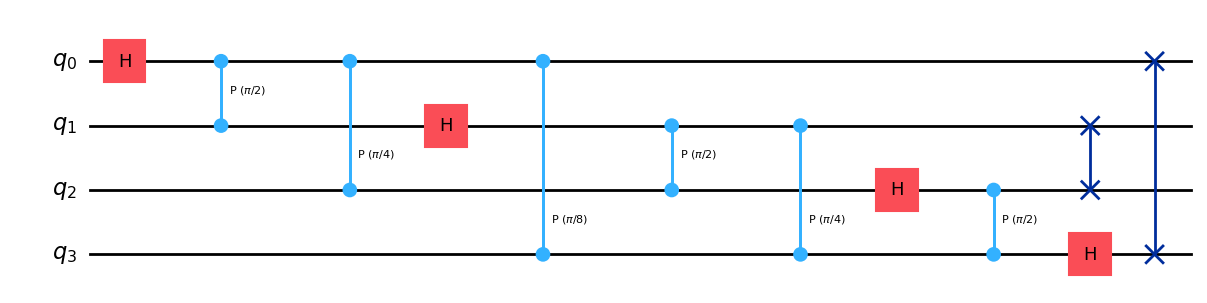

In [116]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import RZGate, RXGate, RYGate

# Create a 5-qubit circuit
"""qc = QuantumCircuit(5)

# Step 1: first simple gates
qc.z(0)
qc.rz(1.43, 0)
qc.z(1)
qc.y(1)
qc.ry(1.06, 2)
qc.rz(0.84, 2)

# Step 2: controlled gates and crossings
qc.cx(0, 1)
qc.cx(1, 2)
qc.cx(2, 3)

# Step 3: other simple gates
qc.ry(1.64, 3)
qc.z(3)
qc.cx(3, 4)
qc.rz(0.24, 4)
qc.cx(4, 3)

# Step 4: additional gates
qc.rz(1.59, 1)
qc.h(0)

# Display the circuit
qc.draw("mpl")
from qiskit import QuantumCircuit
from numpy import pi

qc = QuantumCircuit(7)

qc.z(6)
qc.h(0)
qc.cx(1, 4)
qc.ry(0.1571, 0)
qc.rz(5.9690, 3)
qc.h(6)
qc.z(1)
qc.cx(2, 5)
qc.x(2)
qc.cx(2, 1)
qc.rz(3.6812, 5)
qc.z(0)
qc.cx(4, 6)
qc.rz(2.8656, 0)
qc.ry(3.4968, 1)
qc.ccx(6, 5, 3)
qc.y(1)
qc.ry(2.6381, 0)
qc.cx(3, 6)
qc.cx(2, 6)
qc.ry(3.9715, 1)
qc.z(2)
qc.ry(5.4430, 6)
qc.cx(2, 4)
qc.rz(5.5112, 5)

qc.draw("mpl")


"""



from qiskit import QuantumCircuit
from numpy import pi


qc = QuantumCircuit(4)

    # Qubit 0
qc.h(0)
qc.cp(pi/2, 1, 0)
qc.cp(pi/4, 2, 0)
qc.cp(pi/8, 3, 0)

    # Qubit 1
qc.h(1)
qc.cp(pi/2, 2, 1)
qc.cp(pi/4, 3, 1)

    # Qubit 2
qc.h(2)
qc.cp(pi/2, 3, 2)

    # Qubit 3
qc.h(3)

    # Optionally swap qubits to reverse order
qc.swap(0, 3)
qc.swap(1, 2)

qc.draw('mpl')








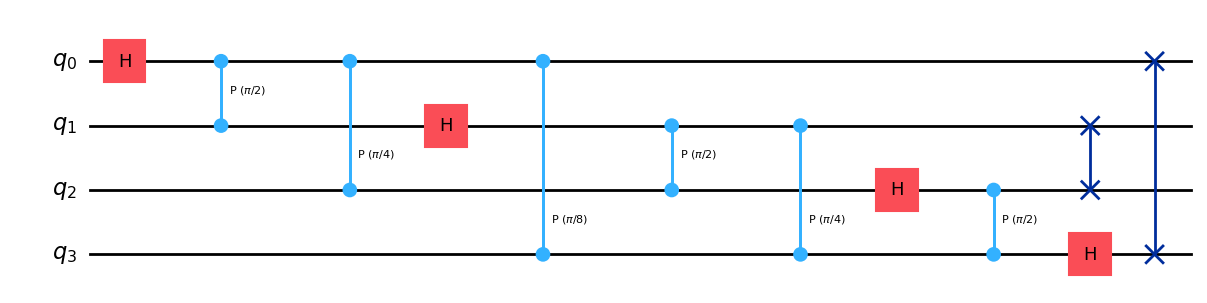

In [117]:
qc.draw('mpl')

In [118]:
unitary_matrix = Operator(qc).data


Génération 1 - Meilleure Fitness: 0.16715

Génération 2 - Meilleure Fitness: 0.16715

Génération 3 - Meilleure Fitness: 0.16715

Génération 4 - Meilleure Fitness: 0.16715

Génération 5 - Meilleure Fitness: 0.16715

Génération 6 - Meilleure Fitness: 0.16715

Génération 7 - Meilleure Fitness: 0.16715

Génération 8 - Meilleure Fitness: 0.20645

Génération 9 - Meilleure Fitness: 0.20645

Génération 10 - Meilleure Fitness: 0.20645

Génération 11 - Meilleure Fitness: 0.20645

Génération 12 - Meilleure Fitness: 0.20645

Génération 13 - Meilleure Fitness: 0.20645

Génération 14 - Meilleure Fitness: 0.20645

Génération 15 - Meilleure Fitness: 0.20743

Génération 16 - Meilleure Fitness: 0.20743

Génération 17 - Meilleure Fitness: 0.20743

Génération 18 - Meilleure Fitness: 0.20743

Génération 19 - Meilleure Fitness: 0.20743

Génération 20 - Meilleure Fitness: 0.20743

Génération 21 - Meilleure Fitness: 0.20743

Génération 22 - Meilleure Fitness: 0.20743

Génération 23 - Meilleure Fitness: 0.207

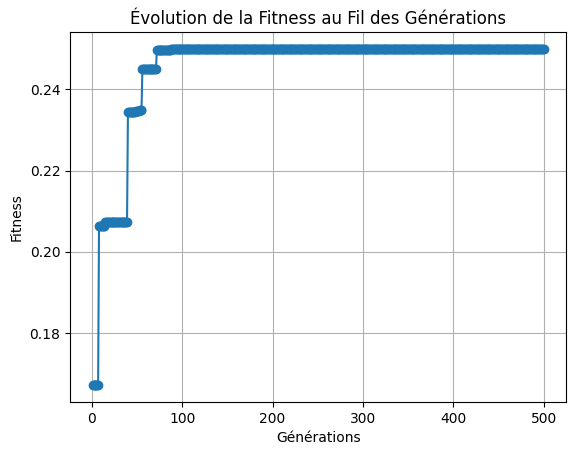

In [119]:
# -------------------- Code Execution --------------------

num_qubits =4
num_genes =12
pop_size = 300
generations = 500


optimized_circuit = genetic_algorithm(num_qubits, num_genes, pop_size, generations, unitary_matrix,elitism=0.1)


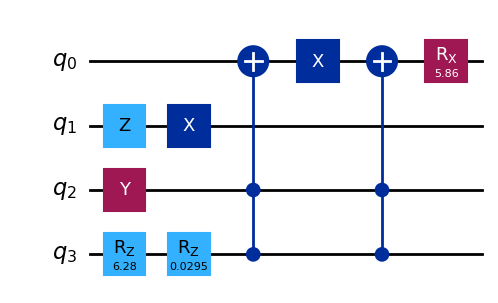

In [120]:
optimized_circuit.draw('mpl', filename='optimizedcircuitaleatoire.png', style='mpl')
    

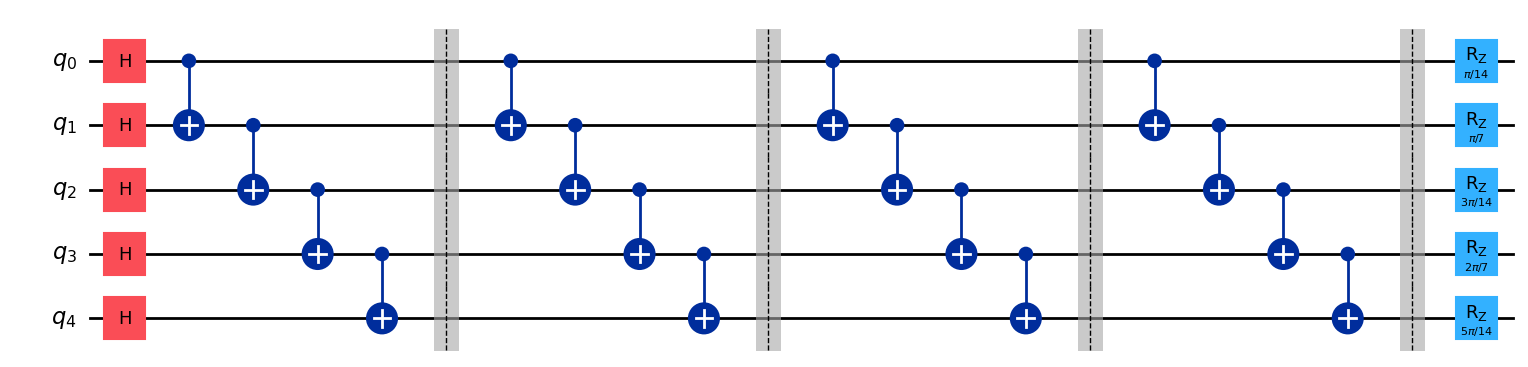

In [121]:


def create_random_circuit(num_qubits=5, num=4):

    # Initialize a quantum circuit
    Random_circuit = QuantumCircuit(num_qubits)

    # Apply gates to represent
    for i in range(num_qubits):
        Random_circuit.h(i)  # Initial superposition

    for m in range(num):
        for j in range(num_qubits - 1):
            Random_circuit.cx(j, j+1)  # Correlation between qubits
        Random_circuit.barrier()

    # Apply rotations to model temporal constraints
    for i in range(num_qubits):
        Random_circuit.rz((i + 1) * np.pi / 14, i)



    return Random_circuit

# Generate the unitary matrix
circuit_cible = create_random_circuit()
circuit_cible.draw('mpl')




In [122]:
def count_gates(circuit):
    return circuit.count_ops()


print("Number of gates (target circuit):", count_gates(circuit_cible))
print("Number of gates (optimized circuit):", count_gates(optimized_circuit))


Nombre de portes (circuit cible) : OrderedDict({'cx': 16, 'h': 5, 'rz': 5, 'barrier': 4})
Nombre de portes (circuit optimisé) : OrderedDict({'rz': 2, 'ccx': 2, 'x': 2, 'z': 1, 'y': 1, 'rx': 1})


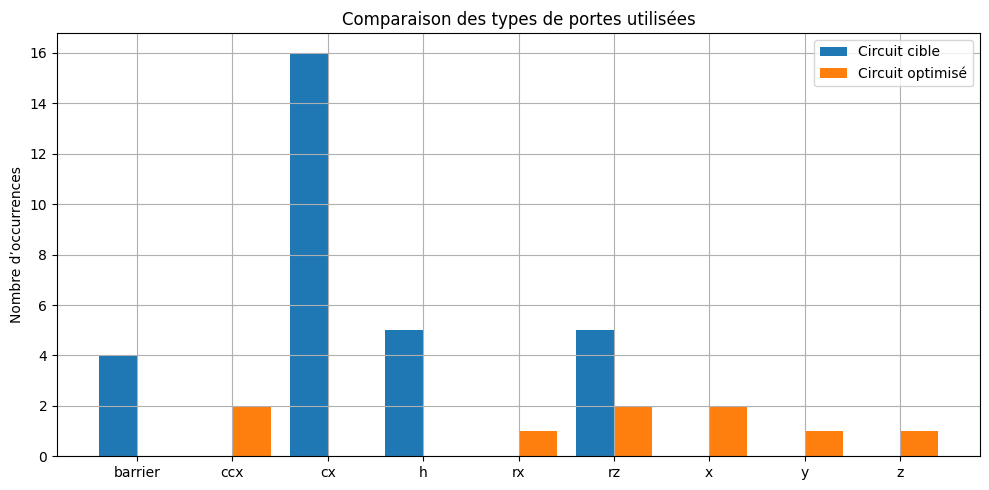

In [123]:
from collections import defaultdict
import matplotlib.pyplot as plt

def plot_gate_counts_comparison(circuit1, circuit2, label1="Target", label2="Optimized"):
    """
    Graphically compares the gates used in two circuits.

    Args:
        circuit1 (QuantumCircuit): first circuit (e.g. target)
        circuit2 (QuantumCircuit): second circuit (e.g. found by GA)
        label1 (str): label of the first circuit
        label2 (str): label of the second circuit
    """
    gates1 = defaultdict(int, circuit1.count_ops())
    gates2 = defaultdict(int, circuit2.count_ops())

    all_gates = sorted(set(gates1.keys()) | set(gates2.keys()))
    counts1 = [gates1[g] for g in all_gates]
    counts2 = [gates2[g] for g in all_gates]

    x = range(len(all_gates))
    plt.figure(figsize=(10, 5))
    plt.bar(x, counts1, width=0.4, label=label1, align='center')
    plt.bar([i + 0.4 for i in x], counts2, width=0.4, label=label2, align='center')
    plt.xticks([i + 0.2 for i in x], all_gates)
    plt.ylabel("Number of occurrences")
    plt.title("Comparison of gate types used")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_gate_counts_comparison(circuit_cible, optimized_circuit, label1="Target circuit", label2="Optimized circuit")


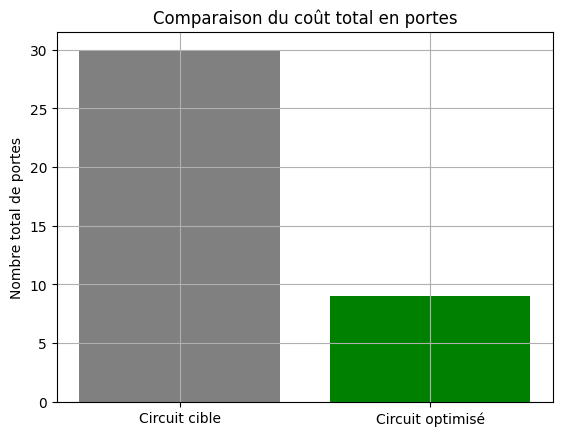

In [124]:
def plot_gate_total_cost(circuit1, circuit2, label1="Target", label2="Optimized"):
    cost1 = sum(circuit1.count_ops().values())
    cost2 = sum(circuit2.count_ops().values())
    plt.bar([label1, label2], [cost1, cost2], color=["gray", "green"])
    plt.ylabel("Total number of gates")
    plt.title("Comparison of total gate cost")
    plt.grid(True)
    plt.show()

plot_gate_total_cost(circuit_cible, optimized_circuit, label1="Target circuit", label2="Optimized circuit")

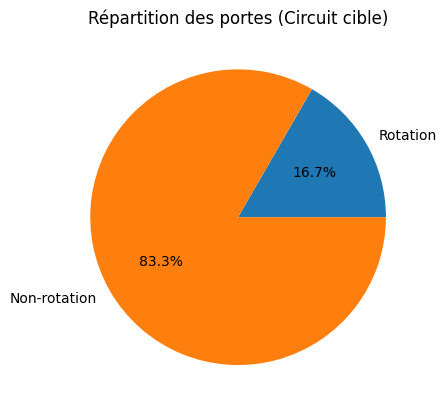

In [125]:
def plot_rotation_vs_nonrotation(circuit, label="Circuit"):
    ops = circuit.count_ops()
    rotation = sum([ops.get(g, 0) for g in ["rx", "ry", "rz"]])
    non_rotation = sum(ops.values()) - rotation
    plt.pie([rotation, non_rotation], labels=["Rotation", "Non-rotation"], autopct="%1.1f%%")
    plt.title(f"Gate distribution ({label})")
    plt.show()

plot_rotation_vs_nonrotation(circuit_cible, label="Target circuit")


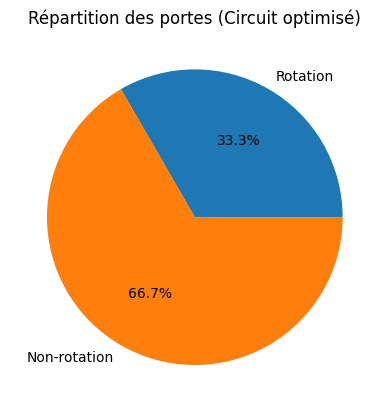

In [126]:
plot_rotation_vs_nonrotation(optimized_circuit, label="Optimized circuit")

In [127]:
def print_circuit_depth(circuit, label="Circuit"):
    print(f"⏱️ Depth of {label}: {circuit.depth()}")

print_circuit_depth(circuit_cible, label="target circuit")
print_circuit_depth(optimized_circuit, label="optimized circuit")

⏱️ Profondeur du circuit cible : 18
⏱️ Profondeur du circuit optimisé : 6


c:\Users\Thinkpad\anaconda3\envs\envq\Lib\site-packages\qiskit\visualization\circuit\matplotlib.py:269: UserWarning: Style JSON file 'mpl.json' not found in any of these locations: c:\Users\Thinkpad\anaconda3\envs\envq\Lib\site-packages\qiskit\visualization\circuit\styles\mpl.json, mpl.json. Will use default style.
  self._style, def_font_ratio = load_style(self._style)


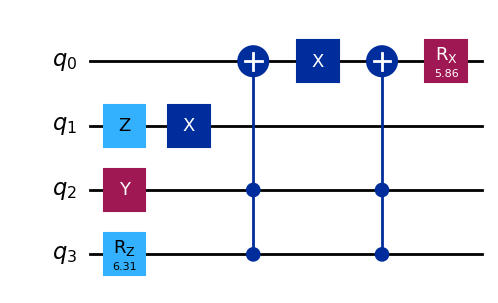

In [128]:
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes import Optimize1qGates, CommutativeCancellation

pm = PassManager([Optimize1qGates(), CommutativeCancellation()])
optimized_circuitqiskit = pm.run(optimized_circuit)
optimized_circuitqiskit.draw('mpl', filename='optimizedcircuitaleatoireqiskitMAXCUT.png', style='mpl')


C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_8136\122323295.py:7: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate1, qargs1, _ = circuit.data[i]
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_8136\122323295.py:8: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate2, qargs2, _ = circuit.data[i+1]
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_8136\122323295.py:22: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate, qargs, _ = circuit.data[-1]


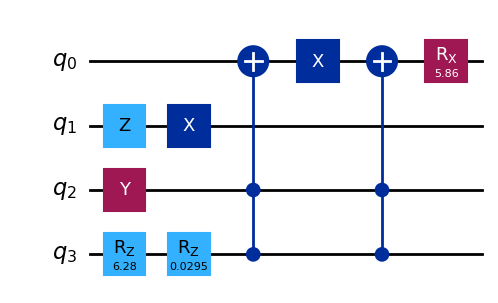

In [ ]:
def cancel_inverse_gates(circuit):
    new_circuit = QuantumCircuit(circuit.num_qubits)
    skip = set()
    for i in range(len(circuit.data)-1):
        if i in skip:
            continue
        gate1, qargs1, _ = circuit.data[i]
        gate2, qargs2, _ = circuit.data[i+1]
        if gate1.name == gate2.name and qargs1 == qargs2:
            if gate1.name in ['x', 'y', 'z', 'h', 'cx']:
                skip.add(i+1)
                continue
            if gate1.name in ['rx', 'ry', 'rz']:
                angle1 = gate1.params[0]
                angle2 = gate2.params[0]
                if np.isclose(angle1 + angle2, 0.0, atol=1e-3):
                    skip.add(i+1)
                    continue
        new_circuit.append(gate1, qargs1)
    # Append last if not skipped
    if (len(circuit.data) - 1) not in skip:
        gate, qargs, _ = circuit.data[-1]
        new_circuit.append(gate, qargs)
    return new_circuit
optimized_circuit1 = cancel_inverse_gates(optimized_circuit)
optimized_circuit1.draw('mpl', filename='optimizedcircuitcancel.png', style='mpl')


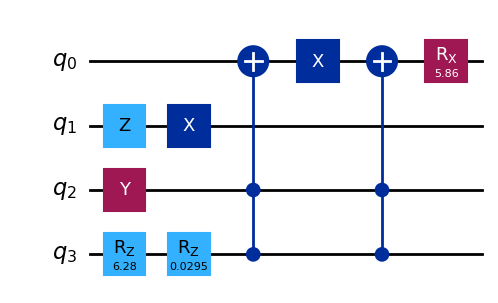

In [130]:
def merge_rotations(circuit):
    num_qubits = circuit.num_qubits
    new_circuit = QuantumCircuit(num_qubits)
    i = 0
    while i < len(circuit.data):
        instruction = circuit.data[i]
        gate = instruction.operation
        qargs = instruction.qubits

        if gate.name in ['rx', 'ry', 'rz']:
            angle = gate.params[0]
            j = i + 1
            while j < len(circuit.data):
                next_inst = circuit.data[j]
                next_gate = next_inst.operation
                next_qargs = next_inst.qubits
                if next_gate.name == gate.name and next_qargs == qargs:
                    angle += next_gate.params[0]
                    j += 1
                else:
                    break
            qindex = circuit.qubits.index(qargs[0])
            getattr(new_circuit, gate.name)(angle, qindex)
            i = j
        else:
            qindices = [circuit.qubits.index(q) for q in qargs]
            new_circuit.append(gate, qindices)
            i += 1

    return new_circuit

optimized_circuit2 = merge_rotations(optimized_circuit)
optimized_circuit2.draw('mpl', filename='optimizedcircuitencoreMERGEaleatoireMAXCUT.png', style='mpl')

C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_8136\1664907163.py:3: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  for gate, qargs, _ in circuit.data:


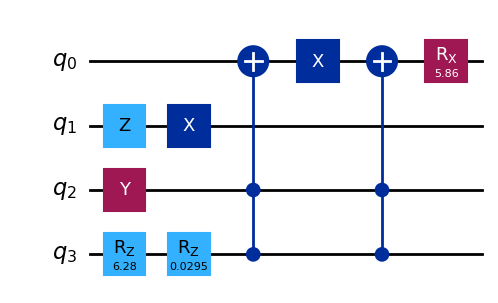

In [131]:
def remove_negligible_rotations(circuit, threshold=1e-4):
    new_circuit = QuantumCircuit(circuit.num_qubits)
    for gate, qargs, _ in circuit.data:
        if gate.name in ['rx', 'ry', 'rz'] and abs(gate.params[0]) < threshold:
            continue  # Skip
        new_circuit.append(gate, qargs)
    return new_circuit
optimized_circuit3 = remove_negligible_rotations(optimized_circuit)
optimized_circuit3.draw('mpl', filename='optimizedcircuitencoreNEGLIGIBLEaleatoireMAXCUT.png', style='mpl')

C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_8136\122323295.py:7: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate1, qargs1, _ = circuit.data[i]
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_8136\122323295.py:8: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate2, qargs2, _ = circuit.data[i+1]
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_8136\122323295.py:22: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate, qargs, _ = circuit.data[-1]
C:\Users\Thinkpad\AppData\Local\Tem

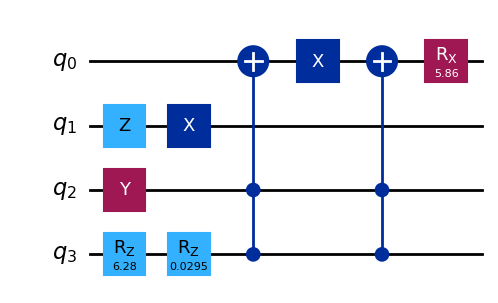

In [132]:
def compress_circuit_custom(circuit):
    c1 = cancel_inverse_gates(circuit)
    c2 = merge_rotations(c1)
    c3 = remove_negligible_rotations(c2)
    return c3
optimized_circuit4 = compress_circuit_custom(optimized_circuit)
optimized_circuit4.draw('mpl', filename='optimizedcircuitencoreCOMPRESSaleatoireMAXCUT.png', style='mpl')

In [133]:
compressed_circuit = compress_circuit_custom(optimized_circuit)
print("Before:", optimized_circuit.count_ops())
print("After compression:", compressed_circuit.count_ops())

F_before = compute_fitness(optimized_circuit, unitary_matrix)
F_after = compute_fitness(compressed_circuit, unitary_matrix)

print(f"🎯 Fidelity before: {F_before:.4f}")
print(f"🎯 Fidelity after: {F_after:.4f}")


Avant : OrderedDict({'rz': 2, 'ccx': 2, 'x': 2, 'z': 1, 'y': 1, 'rx': 1})
Après compression : OrderedDict({'rz': 2, 'ccx': 2, 'x': 2, 'z': 1, 'y': 1, 'rx': 1})
🎯 Fidélité avant : 0.2500
🎯 Fidélité après : 0.2500


C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_8136\122323295.py:7: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate1, qargs1, _ = circuit.data[i]
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_8136\122323295.py:8: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate2, qargs2, _ = circuit.data[i+1]
C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_8136\122323295.py:22: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate, qargs, _ = circuit.data[-1]
C:\Users\Thinkpad\AppData\Local\Tem